In [36]:
import numpy as np
import pandas as pd
from scipy.interpolate import LinearNDInterpolator
import ternary
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from scipy.optimize import brentq

In [31]:
MARG = pd.read_excel(r"All Ternary.xlsx", sheet_name = 'MARG')
VAN = pd.read_excel(r"All Ternary.xlsx", sheet_name = 'VAN')
WILSON = pd.read_excel(r"All Ternary.xlsx", sheet_name = 'WILSON')
COEFFS = pd.read_excel(r"All Ternary.xlsx", sheet_name = 'COEFFS')

In [37]:
COEFFS = {
    ("EtOH", "MeOAc"): {"a12": 0.9314, "a21": 1.3514, "alpha": 0.9314, "beta": 1.3514,
                        "lambda12": 0.7743, "lambda21": 0.3244},
    ("MeOAc", "EtOAc"): {"a12": 0.1536, "a21": 0.0411, "alpha": 0.1536, "beta": 0.0411,
                         "lambda12": 0.4198, "lambda21": 1.7144},
    ("EtOAc", "EtOH"): {"a12": 1.2238, "a21": 0.9704, "alpha": 1.2238, "beta": 0.9704,
                        "lambda12": 0.4011, "lambda21": 0.6897},
}

In [33]:
def get_coeffs(comp1, comp2):
    if (comp1, comp2) in COEFFS:
        return COEFFS[(comp1, comp2)]
    elif (comp2, comp1) in COEFFS:
        c = COEFFS[(comp2, comp1)]
        return {
            "a12": c["a21"], "a21": c["a12"],
            "alpha": c["beta"], "beta": c["alpha"],
            "lambda12": c["lambda21"], "lambda21": c["lambda12"]
        }
    else:
        raise KeyError(f"No coefficients for {comp1}-{comp2}")

In [38]:
def wilson_gamma(x1, x2, x3):
    """Wilson model: Order EtOH(1), MeOAc(2), EtOAc(3)"""
    c12 = get_coeffs("EtOH", "MeOAc")
    c13 = get_coeffs("EtOH", "EtOAc")
    c23 = get_coeffs("MeOAc", "EtOAc")
    
    l12, l21 = c12["lambda12"], c12["lambda21"]
    l13, l31 = c13["lambda12"], c13["lambda21"]
    l23, l32 = c23["lambda12"], c23["lambda21"]
    
    den1 = x1 + l12*x2 + l13*x3
    den2 = l21*x1 + x2 + l23*x3
    den3 = l31*x1 + l32*x2 + x3
    
    lng1 = -np.log(den1) + 1 - (x1/den1 + l21*x2/den2 + l31*x3/den3)
    lng2 = -np.log(den2) + 1 - (l12*x1/den1 + x2/den2 + l32*x3/den3)
    lng3 = -np.log(den3) + 1 - (l13*x1/den1 + l23*x2/den2 + x3/den3)
    
    return np.exp(lng1), np.exp(lng2), np.exp(lng3)


def vanlaar_gamma(x1, x2, x3):
    """Van Laar model"""
    c12 = get_coeffs("EtOH", "MeOAc")
    c13 = get_coeffs("EtOH", "EtOAc")
    c23 = get_coeffs("MeOAc", "EtOAc")
    
    a12, a21 = c12["a12"], c12["a21"]
    a13, a31 = c13["a12"], c13["a21"]
    a23, a32 = c23["a12"], c23["a21"]
    
    g1 = np.exp((a12*x2 + a13*x3)**2 / (x1 + a12*x2 + a13*x3)**2)
    g2 = np.exp((a21*x1 + a23*x3)**2 / (a21*x1 + x2 + a23*x3)**2)
    g3 = np.exp((a31*x1 + a32*x2)**2 / (a31*x1 + a32*x2 + x3)**2)
    
    return g1, g2, g3


def margules_gamma(x1, x2, x3):
    """Margules 3-suffix model"""
    c12 = get_coeffs("EtOH", "MeOAc")
    c13 = get_coeffs("EtOH", "EtOAc")
    c23 = get_coeffs("MeOAc", "EtOAc")
    
    A12, A21 = c12["alpha"], c12["beta"]
    A13, A31 = c13["alpha"], c13["beta"]
    A23, A32 = c23["alpha"], c23["beta"]
    
    lng1 = (x2**2 * A12 + x3**2 * A13 + x2*x3*(A12 + A13 - A23) +
            2*x1*x2*(A12 - A21) + 2*x1*x3*(A13 - A31))
    
    lng2 = (x1**2 * A21 + x3**2 * A23 + x1*x3*(A21 + A23 - A13) +
            2*x1*x2*(A21 - A12) + 2*x2*x3*(A23 - A32))
    
    lng3 = (x1**2 * A31 + x2**2 * A32 + x1*x2*(A31 + A32 - A12) +
            2*x1*x3*(A31 - A13) + 2*x2*x3*(A32 - A23))
    
    return np.exp(lng1), np.exp(lng2), np.exp(lng3)

In [39]:
T = 329.15  # K

def antoine_Psat(A, B, C, T):
    return 10 ** (A - B / (T + C))

Psat_EtOH  = antoine_Psat(5.37229, 1670.409, -40.191, T)
Psat_MeOAc = antoine_Psat(4.20364, 1164.426, -52.69, T)
Psat_EtOAc = antoine_Psat(4.22809, 1245.702, -55.189, T)

print("Psat at 56°C:")
print(f"Ethanol       : {Psat_EtOH:.4f} bar")
print(f"Methyl Acetate: {Psat_MeOAc:.4f} bar")
print(f"Ethyl Acetate : {Psat_EtOAc:.4f} bar")

Psat at 56°C:
Ethanol       : 0.3904 bar
Methyl Acetate: 0.9811 bar
Ethyl Acetate : 0.4798 bar


In [40]:
datasets = {
    "Wilson": {
        "title": "Ternary Diagram - Wilson Method",
        "gamma_func": wilson_gamma,
        "Psat": [Psat_EtOH, Psat_MeOAc, Psat_EtOAc]
    },
    "van Laar": {
        "title": "Ternary Diagram - Van Laar Method",
        "gamma_func": vanlaar_gamma,
        "Psat": [Psat_EtOH, Psat_MeOAc, Psat_EtOAc]
    },
    "Margules": {
        "title": "Ternary Diagram - Margules Method",
        "gamma_func": margules_gamma,
        "Psat": [Psat_EtOH, Psat_MeOAc, Psat_EtOAc]
    }
}

In [41]:
def compute_K(x1, x2, x3, gamma_func, Psat):
    g1, g2, g3 = gamma_func(x1, x2, x3)
    P = x1*g1*Psat[0] + x2*g2*Psat[1] + x3*g3*Psat[2]
    K1 = g1 * Psat[0] / P
    K2 = g2 * Psat[1] / P
    K3 = g3 * Psat[2] / P
    return K1, K2, K3

In [43]:
def plot_ternary_pressure(df, ax, title, scale=100):
    df = df.copy()
    total = df[['x1', 'x2', 'x3']].sum(axis=1)
    df[['x1', 'x2', 'x3']] = df[['x1', 'x2', 'x3']].div(total, axis=0)
    
    points = df[['x1', 'x2']].values
    values = df['P (bar)'].values
    interp = LinearNDInterpolator(points, values)
    
    heatmap_data = {}
    for i in range(scale + 1):
        for j in range(scale + 1 - i):
            k = scale - i - j
            x1, x2 = i/scale, j/scale
            p = interp([[x1, x2]])[0]
            if np.isfinite(p):
                heatmap_data[(i, j, k)] = float(p)
    
    tax = ternary.TernaryAxesSubplot(ax=ax, scale=scale)
    ax.axis("off")
    
    tax.heatmap(heatmap_data, style="triangular", cmap='jet', colorbar=False)
    
    # Colorbar
    norm = mcolors.Normalize(vmin=min(heatmap_data.values()), 
                             vmax=max(heatmap_data.values()))
    sm = cm.ScalarMappable(cmap='jet', norm=norm)
    cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Pressure (bar)", size=14)
    
    tax.boundary(linewidth=1.5)
    tax.gridlines(multiple=10, color="gray", linewidth=0.5, alpha=0.6)
    tax.ticks(axis='lbr', multiple=10, tick_formats="%.0f")
    tax.set_title(title, pad=25, fontsize=16)
    tax.left_axis_label("Ethyl Acetate (mol%)", offset=0.16, fontsize=14)
    tax.right_axis_label("Ethanol (mol%)", offset=0.16, fontsize=14)
    tax.bottom_axis_label("Methyl Acetate (mol%)", offset=0.08, fontsize=14)
    tax.clear_matplotlib_ticks()
    tax._redraw_labels()

In [42]:
def trace_Ki_curve(gamma_func, Psat, component=1, n_points=300):
    """Trace K=1 curve for component i (1=EtOH, 2=MeOAc, 3=EtOAc)"""
    x_sweep = np.linspace(0.001, 0.95, n_points)
    x1_out, x2_out, x3_out = [], [], []
    
    for xs in x_sweep:
        def residual(x):
            if component == 1:   # sweep x2, x3 = 1 - x - xs
                x1, x2, x3 = x, xs, 1 - x - xs
            elif component == 2: # sweep x3, x1 = 1 - x - xs? Wait, better logic:
                x1, x2, x3 = xs, x, 1 - xs - x
            else:                # component 3
                x1, x2, x3 = xs, 1 - xs - x, x
            
            if min(x1, x2, x3) <= 0:
                return np.nan
            Ki = compute_K(x1, x2, x3, gamma_func, Psat)[component-1]
            return Ki - 1.0
        
        try:
            x_max = 1.0 - xs - 1e-6
            if x_max <= 1e-6:
                continue
            fa = residual(1e-6)
            fb = residual(x_max)
            if np.isnan(fa) or np.isnan(fb) or fa * fb > 0:
                continue
            x_sol = brentq(residual, 1e-6, x_max, xtol=1e-8)
            
            if component == 1:
                x1, x2, x3 = x_sol, xs, 1 - x_sol - xs
            elif component == 2:
                x1, x2, x3 = xs, x_sol, 1 - xs - x_sol
            else:
                x1, x2, x3 = xs, 1 - xs - x_sol, x_sol
                
            if min(x1, x2, x3) > 0:
                x1_out.append(x1)
                x2_out.append(x2)
                x3_out.append(x3)
        except:
            continue
    
    return np.array(x1_out), np.array(x2_out), np.array(x3_out)

In [44]:
def plot_k_lines(gamma_func, Psat, ax, title, scale=100):
    tax = ternary.TernaryAxesSubplot(ax=ax, scale=scale)
    ax.axis("off")
    
    colors = ['red', 'blue', 'green']
    styles = ['-', '--', ':']
    labels = ['K1=1 (EtOH)', 'K2=1 (MeOAc)', 'K3=1 (EtOAc)']
    
    for i, comp in enumerate([1, 2, 3], 0):
        x1, x2, x3 = trace_Ki_curve(gamma_func, Psat, component=comp)
        if len(x1) > 5:  # enough points
            pts = [(x1[j]*scale, x2[j]*scale, x3[j]*scale) for j in range(len(x1))]
            cart = [ternary.helpers.project_point(p) for p in pts]
            ax.plot([p[0] for p in cart], [p[1] for p in cart],
                    color=colors[i], linestyle=styles[i], linewidth=2.5, label=labels[i])
    
    tax.boundary(linewidth=1.5)
    tax.gridlines(multiple=10, color="gray", alpha=0.5)
    tax.ticks(axis='lbr', multiple=10, tick_formats="%.0f")
    tax.set_title(title, pad=25, fontsize=16)
    tax.left_axis_label("Ethyl Acetate (mol%)", offset=0.16, fontsize=13)
    tax.right_axis_label("Ethanol (mol%)", offset=0.16, fontsize=13)
    tax.bottom_axis_label("Methyl Acetate (mol%)", offset=0.08, fontsize=13)
    
    ax.legend(loc='upper right', fontsize=11)
    tax.clear_matplotlib_ticks()
    tax._redraw_labels()

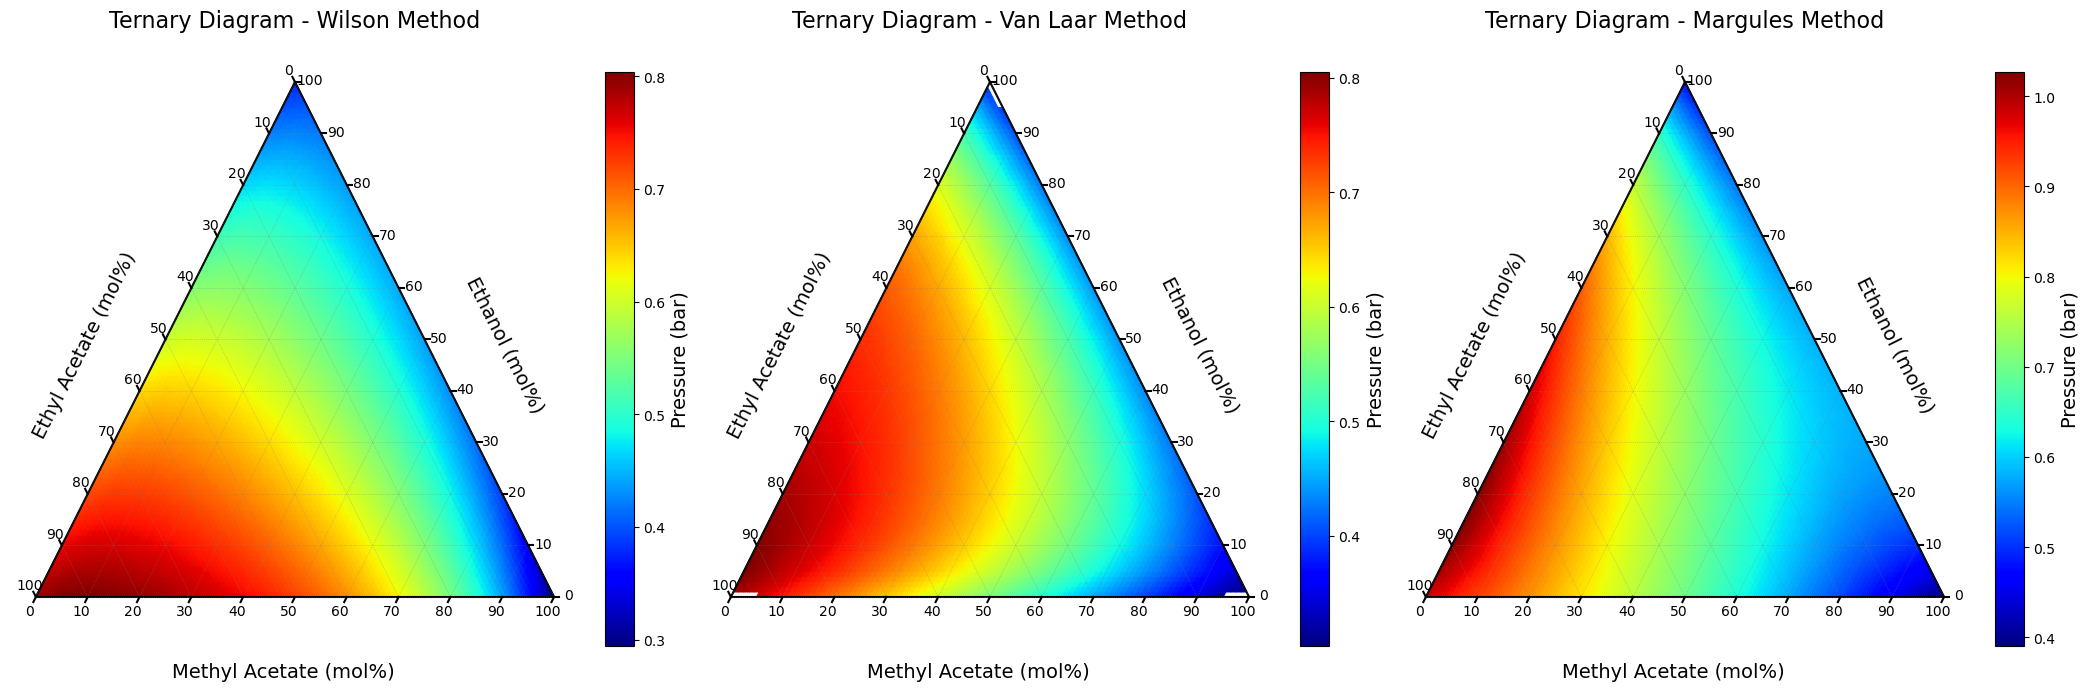

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(21, 7))

for (name, data), ax in zip(datasets.items(), axes):
    if name == "Wilson":
        plot_ternary_pressure(WILSON, ax, data["title"])
    elif name == "van Laar":
        plot_ternary_pressure(VAN, ax, data["title"])
    else:
        plot_ternary_pressure(MARG, ax, data["title"])

plt.tight_layout()
plt.savefig("ternary_pressure_diagrams.png", dpi=300, bbox_inches='tight')
plt.show()

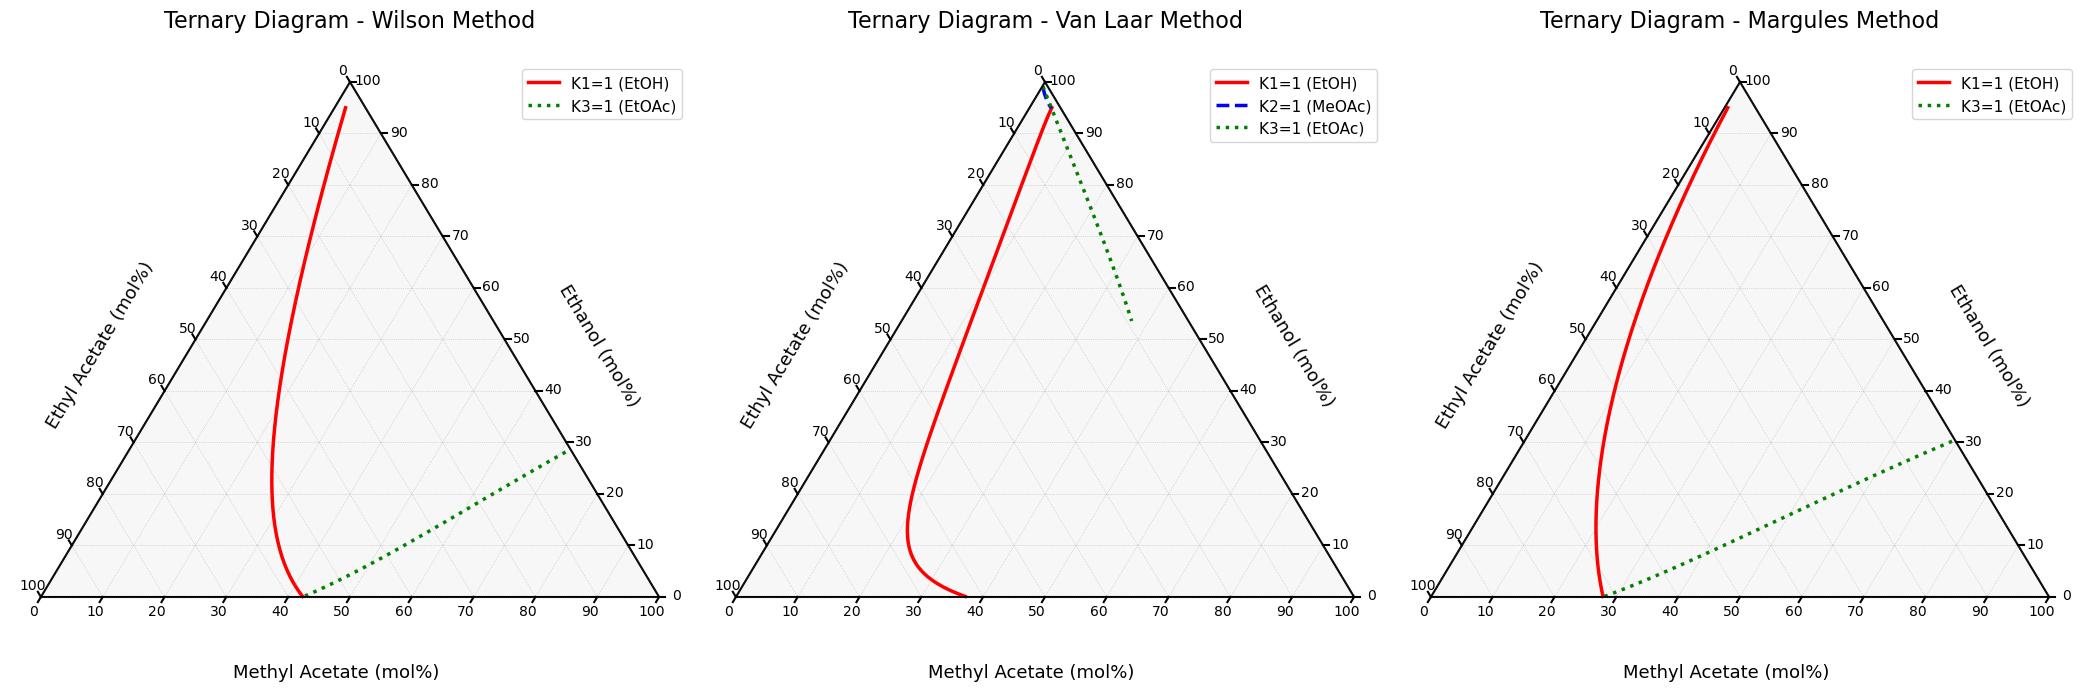

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(21, 7))

for (name, data), ax in zip(datasets.items(), axes):
    plot_k_lines(data["gamma_func"], data["Psat"], ax, data["title"])

plt.tight_layout()
plt.savefig("ternary_K_lines.png", dpi=300, bbox_inches='tight')
plt.show()